In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages
library(readr)
library(readxl)
library(gridExtra)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘gridExtra’




The following object is masked from ‘package:dplyr’:

    combine




[1] "superstore-sales-dataset"

# `Exploratory Data Analysis of Superstore Sales Dataset`

In [2]:
# read data
superstore <- read_excel("/kaggle/input/superstore-sales-dataset/superstore.xls",
                        col_types = c(rep("guess", 11), 
                                      "text",            
                                      rep("guess", 9)))
head(superstore)

Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,⋯,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
<dbl>,<chr>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,⋯,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,⋯,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400,3,0.00,219.5820
3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,⋯,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200,2,0.00,6.8714
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,⋯,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,⋯,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,⋯,90032,West,FUR-FU-10001487,Furniture,Furnishings,"Eldon Expressions Wood and Plastic Desk Accessories, Cherry Wood",48.8600,7,0.00,14.1694


## Initial Data Exploration

In [3]:
# columns
colnames(superstore)

[1] "Row ID"        "Order ID"      "Order Date"    "Ship Date"    
 [5] "Ship Mode"     "Customer ID"   "Customer Name" "Segment"      
 [9] "Country"       "City"          "State"         "Postal Code"  
[13] "Region"        "Product ID"    "Category"      "Sub-Category" 
[17] "Product Name"  "Sales"         "Quantity"      "Discount"     
[21] "Profit"

In [4]:
# dimensions: (Rows, Columns)
dim(superstore)

[1] 9994   21

In [5]:
# Check date range
range(superstore$`Order Date`)

[1] "2014-01-03 UTC" "2017-12-30 UTC"

In [6]:
# info
str(superstore)

tibble [9,994 × 21] (S3: tbl_df/tbl/data.frame)
 $ Row ID       : num [1:9994] 1 2 3 4 5 6 7 8 9 10 ...
 $ Order ID     : chr [1:9994] "CA-2016-152156" "CA-2016-152156" "CA-2016-138688" "US-2015-108966" ...
 $ Order Date   : POSIXct[1:9994], format: "2016-11-08" "2016-11-08" ...
 $ Ship Date    : POSIXct[1:9994], format: "2016-11-11" "2016-11-11" ...
 $ Ship Mode    : chr [1:9994] "Second Class" "Second Class" "Second Class" "Standard Class" ...
 $ Customer ID  : chr [1:9994] "CG-12520" "CG-12520" "DV-13045" "SO-20335" ...
 $ Customer Name: chr [1:9994] "Claire Gute" "Claire Gute" "Darrin Van Huff" "Sean O'Donnell" ...
 $ Segment      : chr [1:9994] "Consumer" "Consumer" "Corporate" "Consumer" ...
 $ Country      : chr [1:9994] "United States" "United States" "United States" "United States" ...
 $ City         : chr [1:9994] "Henderson" "Henderson" "Los Angeles" "Fort Lauderdale" ...
 $ State        : chr [1:9994] "Kentucky" "Kentucky" "California" "Florida" ...
 $ Postal Code  : chr [

In [7]:
# missing values?
colSums(is.na(superstore))

Row ID      Order ID    Order Date     Ship Date     Ship Mode 
            0             0             0             0             0 
  Customer ID Customer Name       Segment       Country          City 
            0             0             0             0             0 
        State   Postal Code        Region    Product ID      Category 
            0             0             0             0             0 
 Sub-Category  Product Name         Sales      Quantity      Discount 
            0             0             0             0             0 
       Profit 
            0

In [8]:
# duplicates?
sum(duplicated(superstore))

[1] 0

In [9]:
# summary statistics
summary(superstore)

     Row ID       Order ID           Order Date                    
 Min.   :   1   Length:9994        Min.   :2014-01-03 00:00:00.00  
 1st Qu.:2499   Class :character   1st Qu.:2015-05-23 00:00:00.00  
 Median :4998   Mode  :character   Median :2016-06-26 00:00:00.00  
 Mean   :4998                      Mean   :2016-04-30 00:07:12.25  
 3rd Qu.:7496                      3rd Qu.:2017-05-14 00:00:00.00  
 Max.   :9994                      Max.   :2017-12-30 00:00:00.00  
   Ship Date                       Ship Mode         Customer ID       
 Min.   :2014-01-07 00:00:00.00   Length:9994        Length:9994       
 1st Qu.:2015-05-27 00:00:00.00   Class :character   Class :character  
 Median :2016-06-29 00:00:00.00   Mode  :character   Mode  :character  
 Mean   :2016-05-03 23:06:58.56                                        
 3rd Qu.:2017-05-18 00:00:00.00                                        
 Max.   :2018-01-05 00:00:00.00                                        
 Customer Name      

In [10]:
# unique customer counts
n_distinct(superstore$`Customer ID`)

[1] 793

In [11]:
# unique product count
n_distinct(superstore$`Product ID`)

[1] 1862

In [12]:
# States
n_distinct(superstore$State)

[1] 49

### Observations:
- Clean data with no missing and duplicate values
- `Sales`
  - **Range:** From **\$0.44** (minimum) to **\$22,638.48** (maximum).
  - **Central Tendency:** The **mean** is **\$229.858** and the **median** is **\$54.490**.
    - *Note:* The large difference between the mean and median indicates a high positive skew, where a few huge orders are significantly pulling up the average.
- `Profit`
  - **Range:** From a minimum loss of **-\$6,599.978** to a maximum gain of **+\$8,399.976**.
  - Some orders lose money!!
- `Discount`
  - **Range:** From minimum of **0%** to maximum **80%**, indicating heavy discounting.
  - **Central Tendency:** The **mean** (average) discount applied is **15.6%**.

## Univariate Analysis

In [13]:
# customer segments
table(superstore$Segment)


   Consumer   Corporate Home Office 
       5191        3020        1783 

In [14]:
# Regions
table(superstore$Region)


Central    East   South    West 
   2323    2848    1620    3203 

In [15]:
# Categories
table(superstore$Category)


      Furniture Office Supplies      Technology 
           2121            6026            1847 

In [16]:
# ship mode
table(superstore$`Ship Mode`)


   First Class       Same Day   Second Class Standard Class 
          1538            543           1945           5968 

In [17]:
# Sub-category
table(superstore$`Sub-Category`)


Accessories  Appliances         Art     Binders   Bookcases      Chairs 
        775         466         796        1523         228         617 
    Copiers   Envelopes   Fasteners Furnishings      Labels    Machines 
         68         254         217         957         364         115 
      Paper      Phones     Storage    Supplies      Tables 
       1370         889         846         190         319 

### Observations
`Customer Segment`
-   Consumer: 5191 (~52%) - Largest segment of customers
-   Corporate: 3020 (30.2%)
-   Home Office: 1783 (17.8%) - Smallest

`Product Categories`
- Office Supplies: 6026 - Most orders
- Furniture: 2121
- Technology: 1847

`Region`
- West: 3203 - Highest
- Central: 2323
- East: 2848
- South: 1620

`Ship Mdde`
- Standard Class: 5968 - Most Common
- First Class: 1538
- Second Class: 1945
- Same Day: 534

`Sub-Category`
- Binders: 1523 (15.2%)
- ....
- ....
- Copiers: 68 (0.68%)
                        

## Discount Analysis

**We observed that there was negative profit and also that there was heavy discounting as well, so let's see if discount affected profits?**

In [18]:
discount_summary <- superstore %>%
  mutate(Discount_Level = case_when(
    Discount == 0 ~ "No Discount",
    Discount > 0 & Discount <= 0.2 ~ "Low (1-20%)",
    Discount > 0.2 & Discount <= 0.4 ~ "Medium (21-40%)",
    Discount > 0.4 ~ "High (40%+)"
  )) %>%
  mutate(Discount_Level = factor(Discount_Level, 
                                 levels = c("No Discount", "Low (1-20%)", 
                                           "Medium (21-40%)", "High (40%+)"))) %>%
  group_by(Discount_Level) %>%
  summarise(
    count = n(),
    avg_profit = mean(Profit),
    total_profit = sum(Profit),
    avg_negative_profit = sum(Profit < 0)
  ) %>%
mutate(percentage = count / sum(count) * 100)

In [19]:
discount_summary

Discount_Level,count,avg_profit,total_profit,avg_negative_profit,percentage
<fct>,<int>,<dbl>,<dbl>,<int>,<dbl>
No Discount,4798,66.90029,320987.60,0,48.008805
Low (1-20%),3803,26.50157,100785.47,523,38.052832
Medium (21-40%),460,-77.86406,-35817.47,415,4.602762
High (40%+),933,-106.70803,-99558.59,933,9.335601


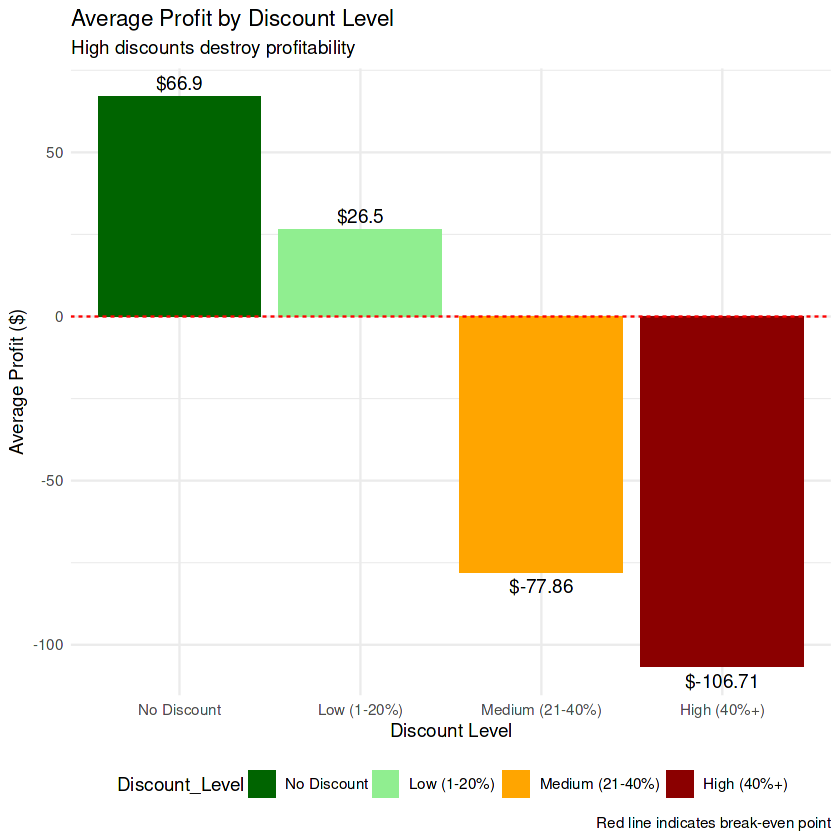

In [20]:
# Visualising: Average Profit by Discount level
ggplot(discount_summary, aes(x = Discount_Level, y = avg_profit, fill = Discount_Level)) +
  geom_col() +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  scale_fill_manual(values = c("darkgreen", "lightgreen", "orange", "darkred")) +
  labs(
    title = "Average Profit by Discount Level",
    subtitle = "High discounts destroy profitability",
    x = "Discount Level",
    y = "Average Profit ($)",
    caption = "Red line indicates break-even point"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom") +
  geom_text(aes(label = paste0("$", round(avg_profit, 2))), 
            vjust = ifelse(discount_summary$avg_profit > 0, -0.5, 1.5))

#### Observation
- As the discount increases, we can see the profits decreasing
- `No Discount` (**48%** of orders)
  - Average Profit: ~**\$67/order**
  - No loss in profits when no discount was given
  - Full sale price are profitable
- `Low Discounnt`
  - Average Profit: ~**\$27/order**
  - Still positive, but **14%** of orders still lose money (523 out of 3803)
  - Small discounts work, but need to be managed carefully
- `Medium Discount`
  - Average **loss** of almost **\-$78%**/order
  - Total Loss: **\$35817.47**
  - **90%** unprofitable (415 orders out of 460)
  - The medium discount range gives more losses than any profit
- `High Discount`
  - Average **loss** of almost **\$107**/order
  - Total Loss: **\$100k**
  - 100% unprofitable (933 out 933 orders)
  - This needs to be stopped if we do not want more losses

This gives us questions, like:
1. Why low discount orders still lose money?
2. What  categories are affecting profits in medium and high discounts?
3. Which products should we flag as `Not to be Discounted`?

In [21]:
# Investigating low discounts
superstore %>%
filter(Discount > 0 & Discount <= 0.2 & Profit < 0) %>%
group_by(Category, `Sub-Category`) %>%
summarise(
    count=n(),
    avg_loss = mean(Profit),
    total_loss = sum(Profit),
    avg_discount = mean(Discount),
    .groups = "drop"   
) %>%
arrange(total_loss)

Category,Sub-Category,count,avg_loss,total_loss,avg_discount
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Office Supplies,Storage,161,-39.914930,-6426.3038,0.2000000
Furniture,Chairs,87,-36.134766,-3143.7246,0.1954023
Office Supplies,Supplies,33,-91.382482,-3015.6219,0.2000000
Furniture,Tables,31,-53.258855,-1651.0245,0.2000000
Furniture,Bookcases,40,-26.361115,-1054.4446,0.1787500
Technology,Accessories,91,-10.226665,-930.6265,0.2000000
Technology,Phones,39,-20.893423,-814.8435,0.2000000
Furniture,Furnishings,29,-18.836490,-546.2582,0.2000000
Office Supplies,Fasteners,12,-2.766267,-33.1952,0.2000000


- Just **20%** discount, yet substantial amount of profit loss
- Office Supplies:
  - Storage: 161 orders --> **\$6426.3038** loss
  - Supplies: 33 orders --> worst average loss (**\$91.4)** at **20%** discount
- Furniture:
  - Chairs: 87 orders --> **\$3143.7246** loss
  - Tables: 31 orders --> **\$1651.0245** loss
  - Bookcases: 40 orders --> **\$1054.445** loss
- Furnitures --> heavy and expensive to ship and then with discounts they incurr losses more than profits

In [22]:
# category by high discount
discount_category <- superstore %>%
filter(Discount > 0.4) %>%
group_by(Category) %>%
summarise(
    count = n(),
    avg_loss = mean(Profit),
    total_loss = sum(Profit),
    avg_discount = mean(Discount)
) %>% 
arrange(total_loss)

In [23]:
discount_category

Category,count,avg_loss,total_loss,avg_discount
<chr>,<int>,<dbl>,<dbl>,<dbl>
Office Supplies,680,-69.32373,-47140.14,0.7441176
Technology,35,-777.55852,-27214.55,0.6314286
Furniture,218,-115.61424,-25203.90,0.5745413


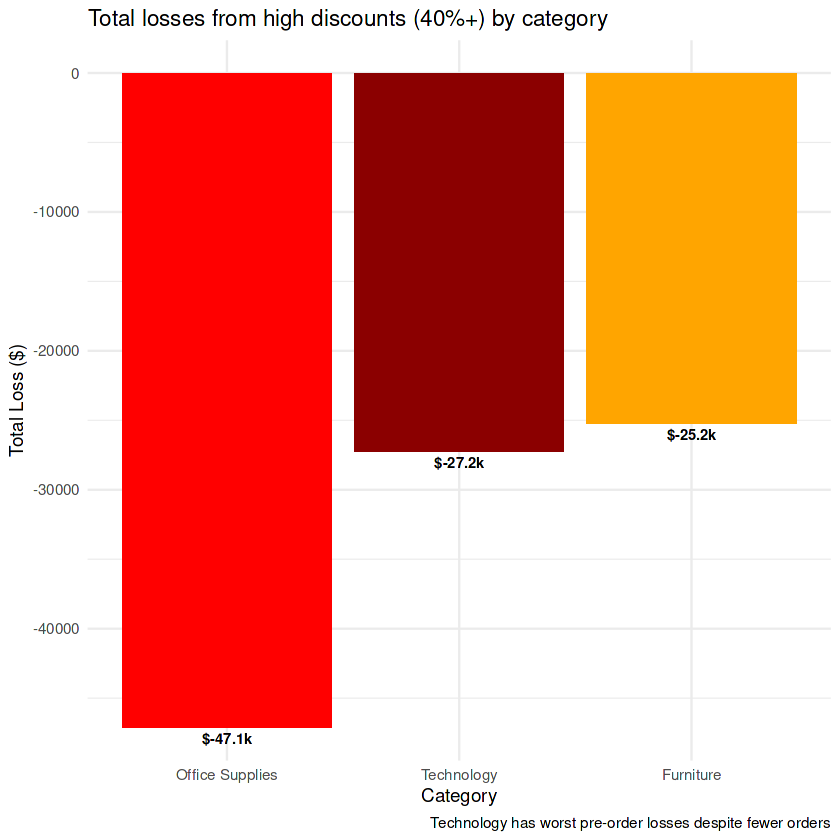

In [24]:
# category loss by discounts Plot
ggplot(discount_category, aes(x = reorder(Category, total_loss), y = total_loss, fill = Category)) +
geom_col() +
# coord_flip() + # horizontal bars
scale_fill_manual(
    values = c(
        "Technology" = "darkred",
        "Office Supplies" = "red",
        "Furniture" = "orange"
    ) 
) +
labs(
    title = "Total losses from high discounts (40%+) by category",
    x = "Category",
    y = "Total Loss ($)",
    caption = "Technology has worst pre-order losses despite fewer orders"
) + 
theme_minimal() +
theme(legend.position = "none") +
geom_text(
    aes(label = paste0("$", round(total_loss/1000, 1), "k")),
    hjust = 0.5, 
    vjust = 1.5, # Moves the label slightly above the bar
    color = "black", 
    size = 3,
    fontface="bold"
)

- Office Supplies: Highest loss of **\$47k**
- Only **35** Technology orders and **\$27k** loss with average loss of **\$778**!!
- **40%+** discount = heavey loss in profits

In [25]:
# category by medium discount
superstore %>%
filter(Discount > 0.2 & Discount <= 0.4 & Profit < 0) %>%
group_by(Category) %>%
summarise(
    count = n(),
    avg_loss = mean(Profit),
    total_loss = sum(Profit),
    avg_discount = mean(Discount)
) %>% 
arrange(total_loss)

Category,count,avg_loss,total_loss,avg_discount
<chr>,<int>,<dbl>,<dbl>,<dbl>
Furniture,309,-94.94095,-29336.75,0.3260194
Technology,106,-90.75377,-9619.90,0.3990566


- At medium discounts, Furniture suffers most. (**309** orders losing money)

In [26]:
# Products never to be discounted
superstore %>%
filter(Discount > 0 & Profit < 0) %>%
group_by(`Sub-Category`) %>%
summarise(
    count=n(),
    avg_loss = mean(Profit),
    total_loss = sum(Profit),
    avg_discount = mean(Discount)
) %>%
arrange(total_loss)

Sub-Category,count,avg_loss,total_loss,avg_discount
<chr>,<int>,<dbl>,<dbl>,<dbl>
Binders,613,-62.822996,-38510.4964,0.7380098
Tables,203,-159.665755,-32412.1483,0.3652709
Machines,44,-684.515186,-30118.6682,0.5818182
Bookcases,109,-111.488128,-12152.2060,0.3485321
Chairs,235,-42.046133,-9880.8413,0.2612766
Appliances,67,-128.800615,-8629.6412,0.8000000
Phones,136,-55.372232,-7530.6235,0.3426471
Furnishings,167,-38.867745,-6490.9134,0.5305389
Storage,161,-39.914930,-6426.3038,0.2000000


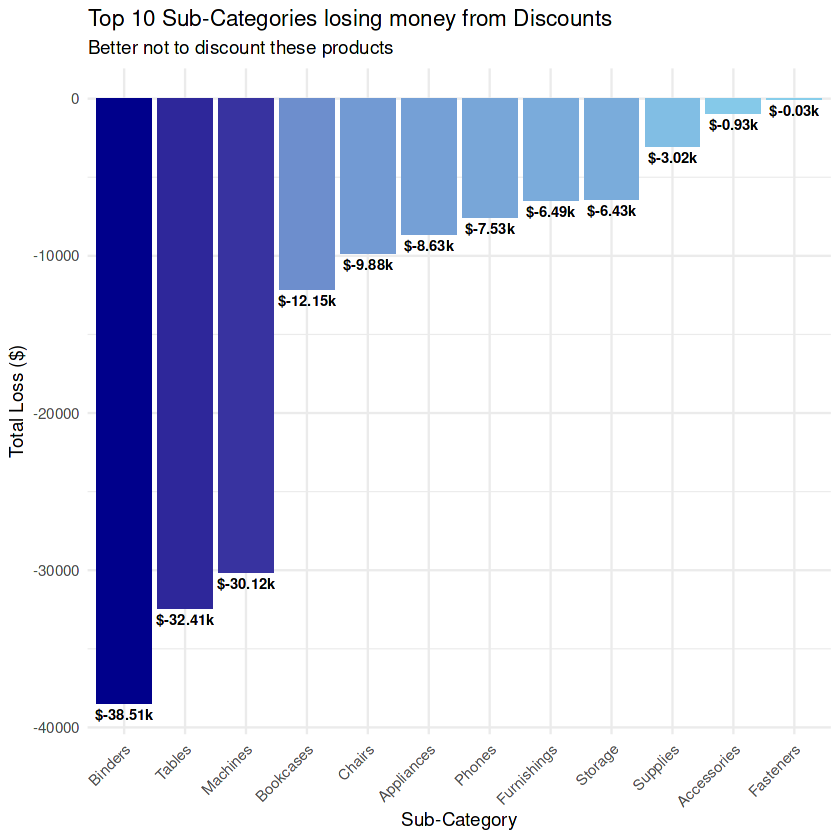

In [27]:
never_discount <- superstore %>%
filter(Discount > 0 & Profit < 0) %>%
group_by(`Sub-Category`) %>%
summarise(
    count=n(),
    avg_loss = mean(Profit),
    total_loss = sum(Profit),
    avg_discount = mean(Discount)
) %>%
arrange(total_loss)

# Plot
ggplot(
    never_discount, 
    aes(
        x = reorder(`Sub-Category`, total_loss), 
        y = total_loss, 
        fill = total_loss
    )
) +
geom_col() + 
# coord_flip() +
scale_fill_gradient(low="darkblue", high="skyblue") +
labs(
    title = "Top 10 Sub-Categories losing money from Discounts",
    subtitle = "Better not to discount these products",
    x = "Sub-Category",
    y = "Total Loss ($)"
) +
theme_minimal() + 
theme(legend.position = "none", axis.text.x = element_text(angle = 45, hjust = 1)) +
geom_text(
    aes(label = paste0("$", round(total_loss/1000, 2), "k")),
    hjust = 0.5,
    vjust = 1.5, # Moves the label slightly above the bar
    color = "black", 
    size = 3, fontface = "bold"
)

Top products with high losses:
- `Binders`: Loss of **\$38510.4964** with an average discount of **74%**, most discounted and then heavy loss
- `Machines`: Loss  of **\$30118.6682** with an average loss of **\$685**/order
- `Tables`: Loss of **\$32412.1483** with an average loss of **\$160**/order (Worst)
- `Appliances`: Loss of **\$8629.6** with an average loss of **\$129**/order and **80%** discount!!

Do not Discount:
- `Machines`
- `Binders` (already very discounted)
- `Tables`
- `Appliances` (80% discount too much)

Discount with **extreme** caution (<10%):
- Storage
- Supplies
- Bookcases
- Chairs

Safe to discount moderately(10-15%):
- Accessories and Fasteners (managable losses)

## Regional Analysis

In [28]:
regional_performance <- superstore %>%
group_by(Region) %>%
summarise(
    orders = n(),
    total_sales = sum(Sales),
    avg_sales = mean(Sales),
    total_profit = sum(Profit),
    average_profit_per_order = mean(Profit),
    profit_margin = (sum(Profit) / sum(Sales)) * 100,
    unprofitable_orders = sum(Profit < 0),
    percentage_unprofitable = (sum(Profit < 0) / n()) * 100
) %>%
arrange(desc(total_profit))

regional_performance

Region,orders,total_sales,avg_sales,total_profit,average_profit_per_order,profit_margin,unprofitable_orders,percentage_unprofitable
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
West,3203,725457.8,226.4932,108418.45,33.84903,14.944831,318,9.928192
East,2848,678781.2,238.3361,91522.78,32.13581,13.483399,553,19.417135
South,1620,391721.9,241.8036,46749.43,28.85767,11.934342,259,15.987654
Central,2323,501239.9,215.7727,39706.36,17.09271,7.921629,741,31.898407


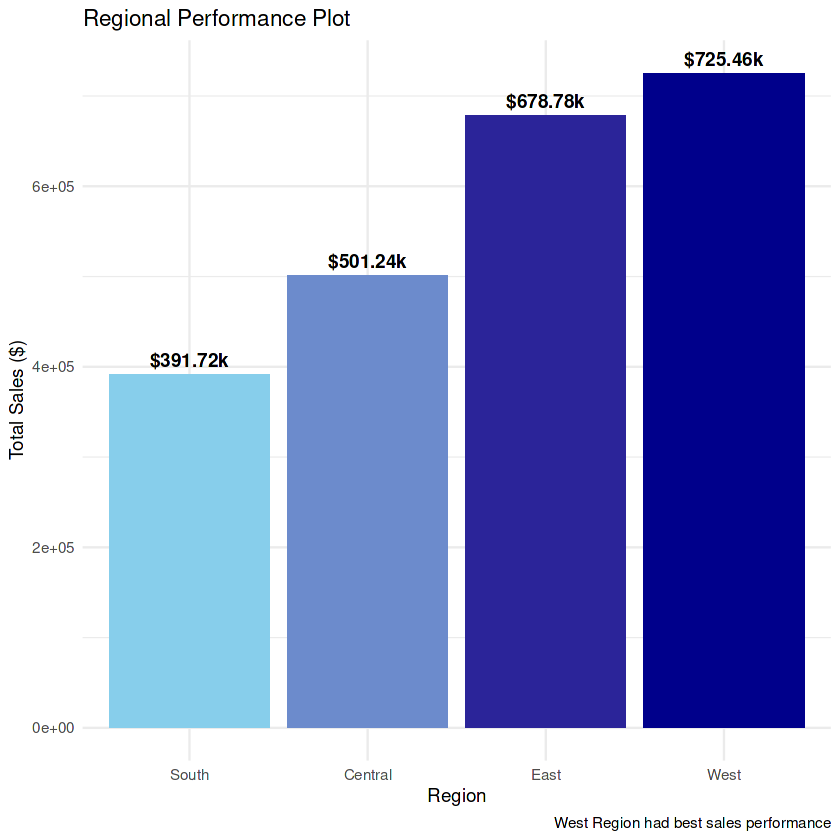

In [29]:
# Plot
ggplot(regional_performance, aes(x = reorder(Region, total_sales), y = total_sales, fill = total_sales)) +
geom_col() + 
scale_fill_gradient(low = "skyblue", high = "darkblue") + 
labs(
    title = "Regional Performance Plot",
    caption = "West Region had best sales performance",
    x = "Region",
    y = "Total Sales ($)"
) + 
theme_minimal() +
theme(legend.position = "none") + 
geom_text(
    aes(label = paste0("$", round(total_sales/1000, 2), "k")),
    vjust = -0.5,
    color = "black",
    fontface = "bold"
)

`West Region` has highest **total sales** and **total prfit**

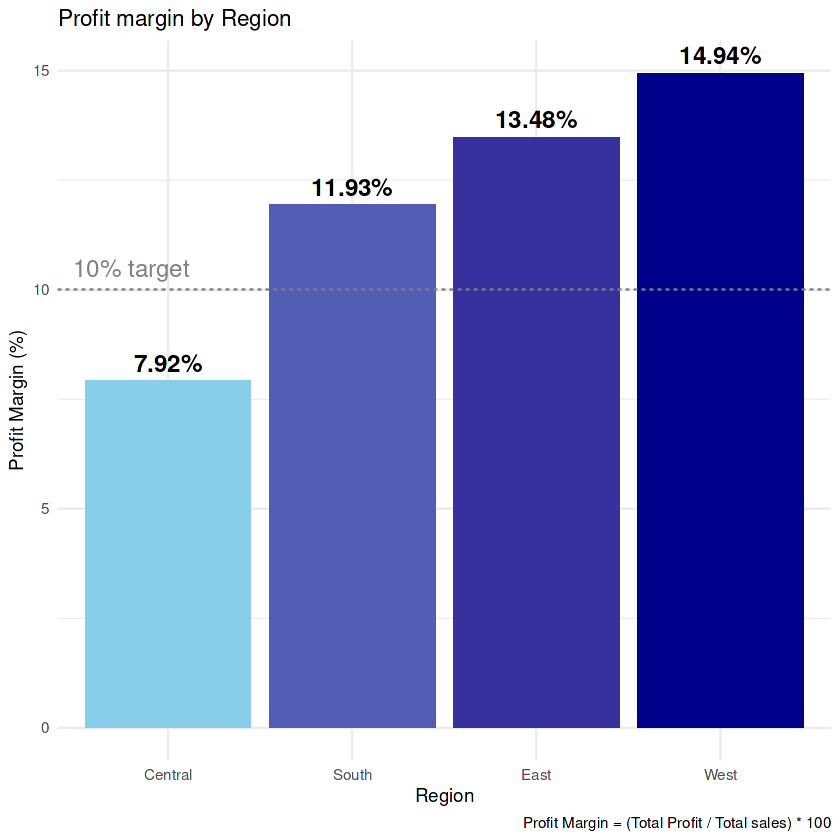

In [30]:
# Profit margin comparison
ggplot(
    regional_performance,
    aes(x=reorder(Region, profit_margin), y=profit_margin, fill=profit_margin)
) + 
geom_col() +
scale_fill_gradient(
    low="skyblue",
    high="darkblue"
) +
labs(
    title="Profit margin by Region",
    x="Region",
    y="Profit Margin (%)",
    caption="Profit Margin = (Total Profit / Total sales) * 100"
) +
theme_minimal() +
theme(legend.position = "none") +
geom_text(
    aes(label = paste0(round(profit_margin, 2), "%")),
    vjust = -0.5, fontface="bold", size=5
) +
geom_hline(
    yintercept = 10, linetype = "dashed", color="gray50"    # 10% target line
) + 
annotate("text", x = 0.8, y = 10.5, label = "10% target", color = "gray50", size = 5)

The **profit margin** of `Central Region` is below **10%**

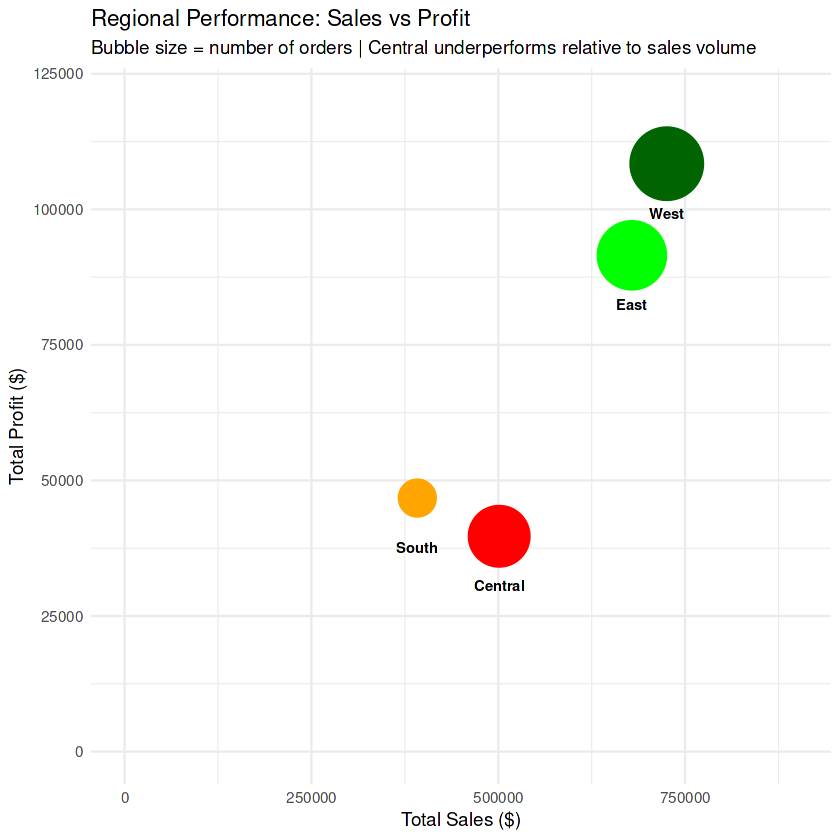

In [31]:
# proft vs sales scatter plot
ggplot(
    regional_performance,
    aes(x=total_sales, y=total_profit, color=Region, size=orders)
) +
geom_point() + # for scatter plot
scale_color_manual(values = c("West" = "darkgreen", 
                                "East" = "green", 
                                "South" = "orange", 
                                "Central" = "red")) + 
scale_size_continuous(range=c(10, 20)) + # bubble size range
labs(
    title="Regional Performance: Sales vs Profit",
    x="Total Sales ($)",
    y="Total Profit ($)",
    subtitle = "Bubble size = number of orders | Central underperforms relative to sales volume"
) +
theme_minimal() + 
theme(legend.position="none") +
geom_text(
    aes(label=Region),
    vjust=5,
    size=3,
    color="black",
    fontface="bold"
) +
coord_cartesian(
    xlim = c(0, 900000), # Extends the X-axis (Sales) past the West's $725k
    ylim = c(0, 120000)  # Extends the Y-axis (Profit) past the West's $108k
)

`West Region`
- West region is the clear winner with highest total sales (**\~\$725k**) and highest total profit (**\~\$108k**)
- Profit margin of **14.9%** (best profit margin)
- Lowest percentage (**9.9%**) of unprofitable orders

`East Region`
- East region is another relaible contributor which is second in sales (**\~\$679k**) and profit (**\~\$92k**)
- A good Profit margin of **13.5%**
- But there is **19.4%** of unprofitable orders which needs attention

`South Region`
- Has fewer orders but higher transaction values, that is, highest average sale per order (**\~\$242**) leading to mixed bag result
- Despite higher average sale per order, it only ranks in 3rd in total profit (**\~\$47k**)
- Has **16%** unprfitable orders

`Central Region`
- The central region requires immediate attention!!
- Profit margin, lowest at **7.9%**
- Highest unprofitable orders (**31.9%**) - nearly 1 in 3 orders lose money!
- Despite having **2,323** orders, the profit is only **\~\$40k**!!

**What could be reasons for low profit margins in the regions, specially central?**
- Too many high discount in the region?
- Category or Product issues?
- Customer Segment issues?

Let's investigate the reason

In [32]:
# Discount behaviour by region
regional_discount_behaviour <- superstore %>%
  mutate(Discount_Level = case_when(
    Discount == 0 ~ "No Discount",
    Discount > 0 & Discount <= 0.2 ~ "Low (1-20%)",
    Discount > 0.2 & Discount <= 0.4 ~ "Medium (21-40%)",
    Discount > 0.4 ~ "High (40%+)"
  )) %>%
group_by(Region, Discount_Level) %>%
summarise(
    orders = n(),
    avg_profit = mean(Profit),
    total_profit = sum(Profit),
    .groups = 'drop'
) %>%
group_by(Region) %>%
mutate(
    percentage = (orders / sum(orders)) * 100
) %>%
arrange(
    Region, Discount_Level
)

regional_discount_behaviour

Region,Discount_Level,orders,avg_profit,total_profit,percentage
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Central,High (40%+),456,-89.45930,-40793.439,19.6297891
Central,Low (1-20%),852,18.74788,15973.196,36.6767111
Central,Medium (21-40%),187,-62.02586,-11598.835,8.0499354
Central,No Discount,828,91.93894,76125.441,35.6435644
East,High (40%+),204,-118.71395,-24217.645,7.1629213
East,Low (1-20%),938,30.10004,28233.841,32.9353933
East,Medium (21-40%),257,-69.53682,-17870.963,9.0238764
East,No Discount,1449,72.72432,105377.546,50.8778090
South,High (40%+),155,-119.56654,-18532.814,9.5679012


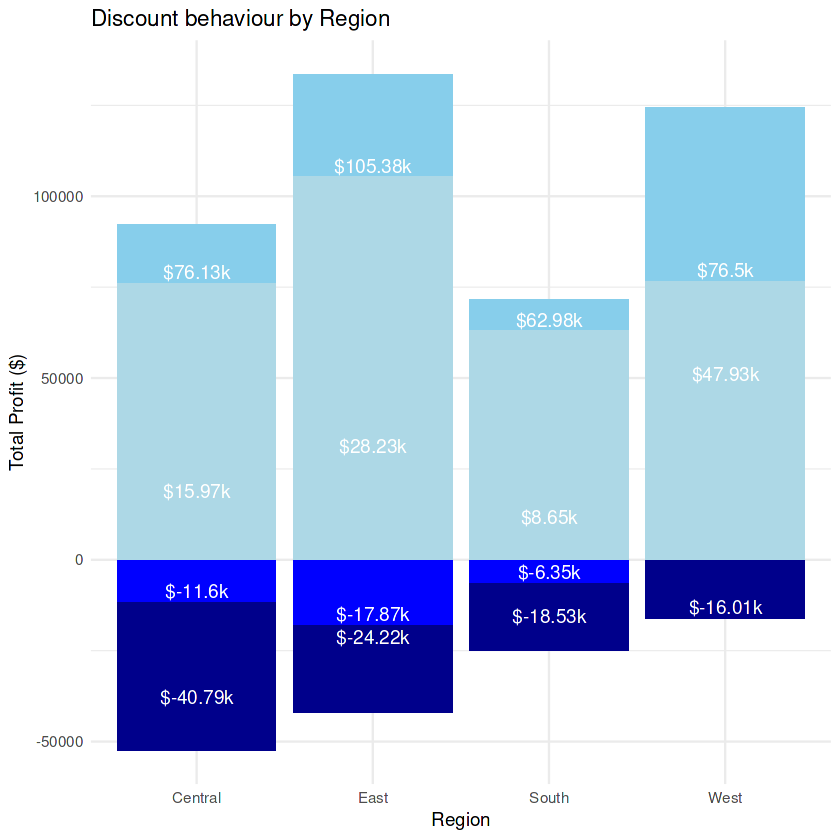

In [33]:
# stacked bar plot for better understanding
ggplot(
    regional_discount_behaviour,
    aes(
        x = Region,
        y = total_profit,
        fill = Discount_Level
    )
) +
geom_bar(
    stat = "identity"
) +
scale_fill_manual(
    values = c("No Discount" = "lightblue", 
               "Low (1-20%)" = "skyblue", 
               "Medium (21-40%)" = "blue", 
               "High (40%+)" = "darkblue") 
) +
labs(
    title = "Discount behaviour by Region",
    x = "Region",
    y = "Total Profit ($)"
) +
theme_minimal() +
theme(legend.position = "none") +
geom_text(
    aes(label = paste0("$", round(total_profit/1000, 2), "k")),
    vjust = -0.3,
    color="white"
)

`Central` gives highest discount on **19.6%** of orders as compared to other regions, specially `West` which only gives **3.7%** high discounts. **5x** more high discount orders than `West` 

In [34]:
# Product Category by Region
regional_orders <- superstore %>%
group_by(Region, Category) %>%
summarise(
    orders=n(),
    total_sales = sum(Sales),
    total_profit = sum(Profit),
    profit_margin = (sum(Profit) / sum(Sales) * 100),
    .groups = "drop"
) %>%
group_by(Region) %>%
mutate(
    percentage_orders = (orders / sum(orders)) * 100
)

regional_orders

Region,Category,orders,total_sales,total_profit,profit_margin,percentage_orders
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Central,Furniture,481,163797.2,-2871.049,-1.752808,20.70598
Central,Office Supplies,1422,167026.4,8879.980,5.316512,61.21395
Central,Technology,420,170416.3,33697.432,19.773595,18.08007
East,Furniture,601,208291.2,3046.166,1.462455,21.10253
East,Office Supplies,1712,205516.1,41014.579,19.956873,60.11236
East,Technology,535,264974.0,47462.035,17.911961,18.78511
South,Furniture,332,117298.7,6771.206,5.772619,20.49383
South,Office Supplies,995,125651.3,19986.393,15.906235,61.41975
South,Technology,293,148771.9,19991.831,13.437908,18.08642


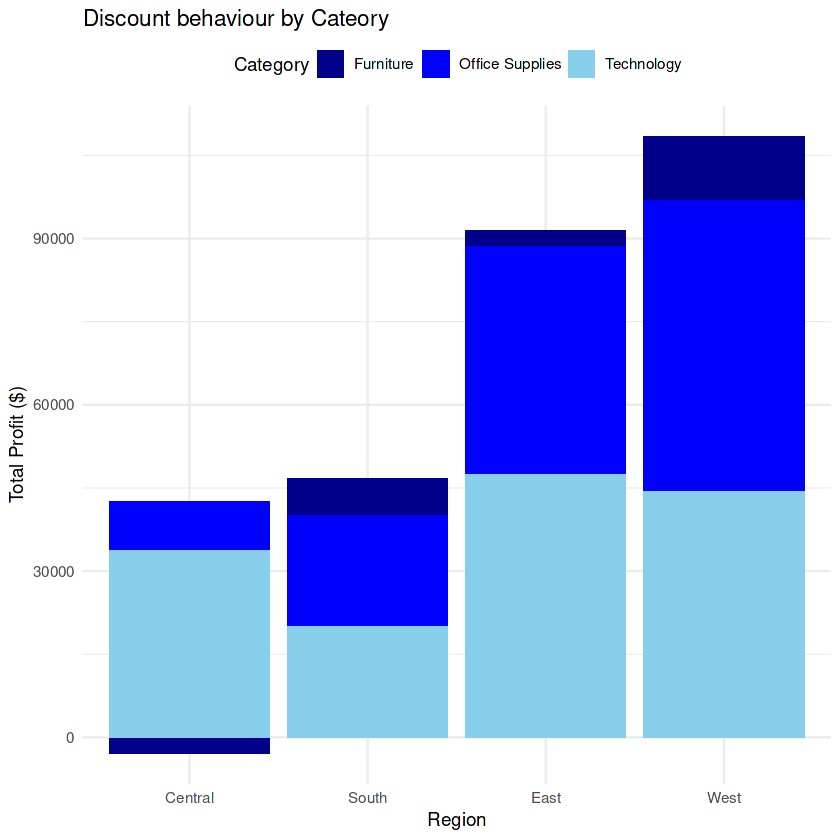

In [35]:
# stacked bar plot for better understanding
ggplot(
    regional_orders,
    aes(
        x = reorder(Region, total_profit),
        y = total_profit,
        fill = Category
    )
) +
geom_bar(
    stat = "identity"
) +
scale_fill_manual(
    values = c("Technology" = "skyblue", 
               "Office Supplies" = "blue", 
               "Furniture" = "darkblue") 
) +
labs(
    title = "Discount behaviour by Cateory",
    x = "Region",
    y = "Total Profit ($)"
) +
theme_minimal() +
theme(legend.position = "top")

`Central` is the only region losing money on **Furniture** with a profit margin of **-1.8%**

```
Central is the most problematic, let's look into it
We will take high discount as more than **20%** for simplicity since earlier analysis told us that above **20%** is bad
```
- Highest % of high discounts (**19.6%**)
- only region with negative Furniture profit
- Worst profit margin (**7.9%**)
- Highest % unprofitable orders (**31.9%**)
- Loses money on both **Furniture** and heavy discounting

In [36]:
region_central <- superstore %>%
filter(
    Region == "Central"
) %>%
  mutate(Discount_Level = case_when(
    Discount == 0 ~ "No Discount",
    Discount > 0 & Discount <= 0.2 ~ "Low (1-20%)",
    Discount > 0.2 ~ "High (40%+)"
  )) %>%
group_by(Category, Discount_Level) %>%
summarise(
    orders = n(),
    avg_profit = mean(Profit),
    total_profit = sum(Profit),
    unprofitable_orders = sum(Profit < 0),
    pct_unprofitable = (sum(Profit < 0) / n()) * 100,
    .groups = 'drop'
) %>%
arrange(Category, Discount_Level)

region_central

Category,Discount_Level,orders,avg_profit,total_profit,unprofitable_orders,pct_unprofitable
<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>
Furniture,High (40%+),325,-60.038250,-19512.431,317,97.53846
Furniture,No Discount,156,106.675525,16641.382,0,0.00000
Office Supplies,High (40%+),300,-101.796797,-30539.039,300,100.00000
Office Supplies,Low (1-20%),605,7.745983,4686.320,75,12.39669
Office Supplies,No Discount,517,67.181237,34732.699,0,0.00000
Technology,High (40%+),18,-130.044661,-2340.804,9,50.00000
Technology,Low (1-20%),247,45.695856,11286.876,40,16.19433
Technology,No Discount,155,159.686190,24751.359,0,0.00000


- `Furniture`: **325** high discount orders, loss of **\$-19512.4** --> **97.5%** unprofitable
- `Office Supplies`: **300** high discount orders, loss of **\$30539.039** --> **100%** unprofitable
- High disocunt --> lose money

A diagnostic plot to look at `Central` Region

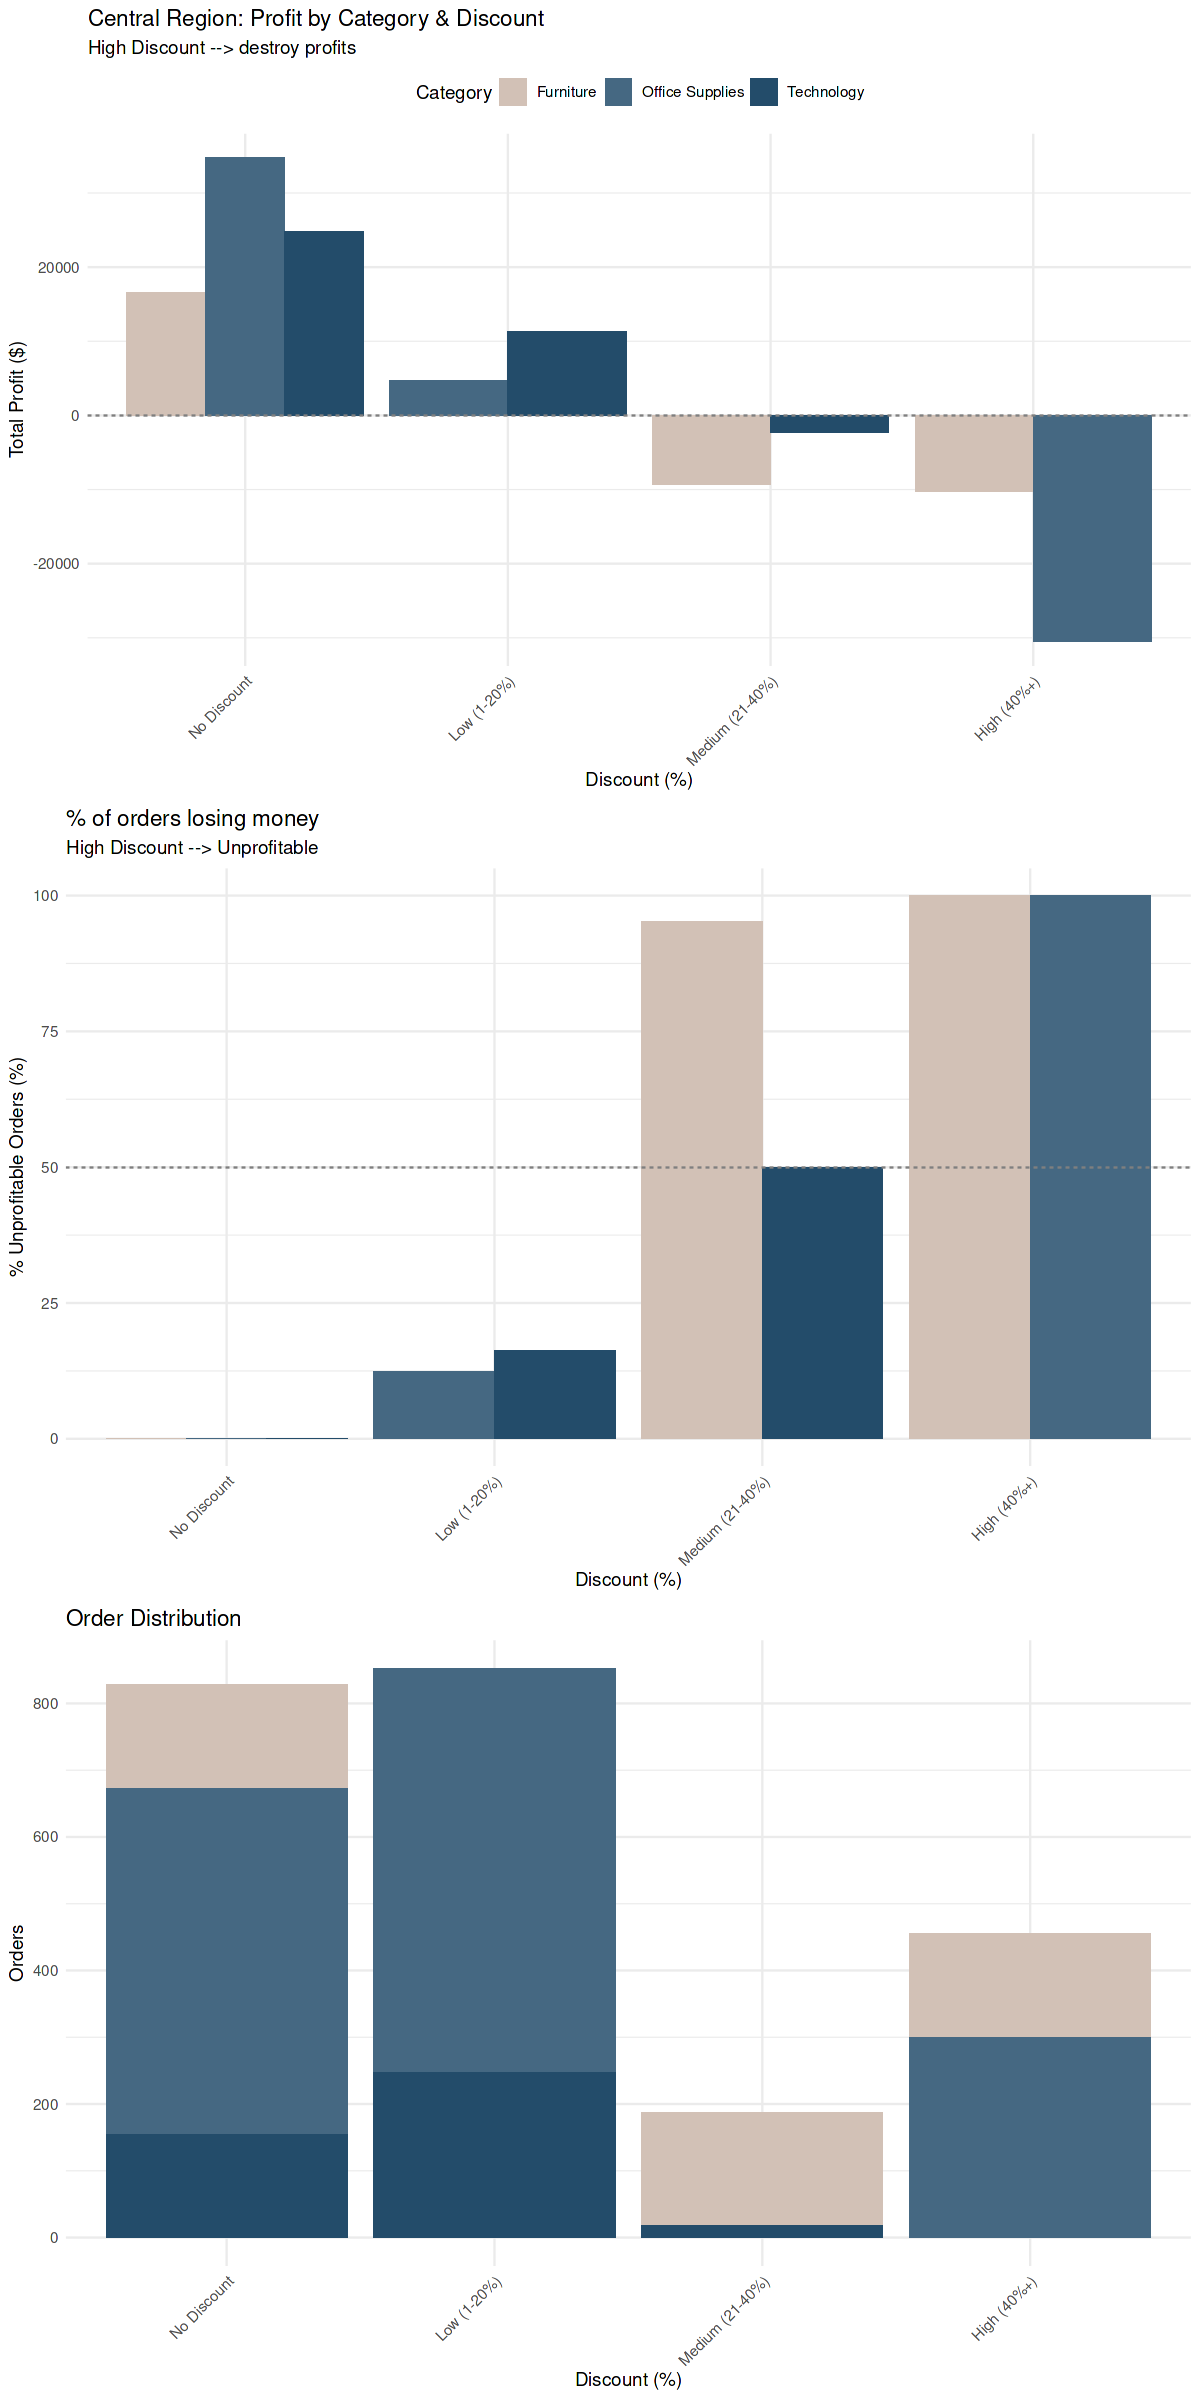

In [37]:
# central data
central_data <- superstore %>%
filter(Region == "Central") %>%
  mutate(
    Discount_Level = case_when(
      Discount == 0 ~ "No Discount",
      Discount > 0 & Discount <= 0.2 ~ "Low (1-20%)",
      Discount > 0.2 & Discount <= 0.4 ~ "Medium (21-40%)",
      Discount > 0.4 ~ "High (40%+)"
    ),
      Discount_Level = factor(
          Discount_Level, levels = c("No Discount", 
                                     "Low (1-20%)", 
                                     "Medium (21-40%)",
                                     "High (40%+)"
                                    )
      )
)

# plot1: Profit by Category & Discount
plot_first <- central_data %>%
group_by(Category, Discount_Level) %>%
summarise(total_profit = sum(Profit), .groups = 'drop') %>%
ggplot(
    aes(x = Discount_Level, y = total_profit, fill = Category)
) + 
geom_col(position = "dodge") +  # for side by side bars
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  scale_fill_manual(values = c("Furniture" = "#D2C1B6", 
                                "Office Supplies" = "#456882", 
                                "Technology" = "#234C6A")) + 
labs(
    title = "Central Region: Profit by Category & Discount",
    x = "Discount (%)",
    y = "Total Profit ($)",
    subtitle = "High Discount --> destroy profits"
) +
theme_minimal() + 
theme(
    legend.position = "top",
    axis.text.x = element_text(angle = 45, hjust = 1)
)

# plot_first

# plot 2: U nprofitable Order rate
plot_second <- central_data %>%
group_by(Category, Discount_Level) %>%
summarise(
    percentage_unprofitable = (sum(Profit < 0) / n()) * 100,
    .groups = 'drop'
) %>%
ggplot(
    aes(x = Discount_Level, y = percentage_unprofitable, fill = Category)
) + 
geom_col(position = "dodge") + 
geom_hline(yintercept = 50, linetype = "dashed", color = "gray50") +
scale_fill_manual(values = c("Furniture" = "#D2C1B6", 
                            "Office Supplies" = "#456882", 
                            "Technology" = "#234C6A")) +
labs(
    title = "% of orders losing money",
    x = "Discount (%)",
    y = "% Unprofitable Orders (%)",
    subtitle = "High Discount --> Unprofitable"
) +
theme_minimal() + 
theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1)
)

# plot_second

# plot 3: Orders distribution
plot_third <- central_data %>%
group_by(Category, Discount_Level) %>%
summarise(
    orders = n(),
    .groups = 'drop'
) %>%
ggplot(
    aes(x = Discount_Level, y = orders, fill = Category)
) + 
geom_col() +
scale_fill_manual(values = c("Furniture" = "#D2C1B6", 
                            "Office Supplies" = "#456882", 
                            "Technology" = "#234C6A")) +
labs(
    title = "Order Distribution",
    x = "Discount (%)",
    y = "Orders",
) +
theme_minimal() + 
theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1)
)

options(repr.plot.width = 10, repr.plot.height = 20)
grid.arrange(plot_first, plot_second, plot_third, ncol = 1)

## Customer Segment Analysis

In [38]:
# customer segment overview
segment_overview <- superstore %>%
group_by(Segment) %>%
summarise(
    orders = n(),
    total_sales = sum(Sales),
    total_profit = sum(Profit),
    avg_order_value = mean(Sales),
    avg_profit_per_order = mean(Profit),
    profit_margin = (sum(Profit) / sum(Sales)) * 100,
    unprofitable_orders = sum(Profit < 0),
    percentage_unprofitable = (sum(Profit < 0) / n()) * 100
) %>%
arrange(desc(total_profit))

segment_overview

Segment,orders,total_sales,total_profit,avg_order_value,avg_profit_per_order,profit_margin,unprofitable_orders,percentage_unprofitable
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
Consumer,5191,1161401.3,134119.21,223.7336,25.83687,11.54805,1003,19.3219
Corporate,3020,706146.4,91979.13,233.8233,30.45667,13.02551,556,18.4106
Home Office,1783,429653.1,60298.68,240.9720,33.81866,14.03427,312,17.4986


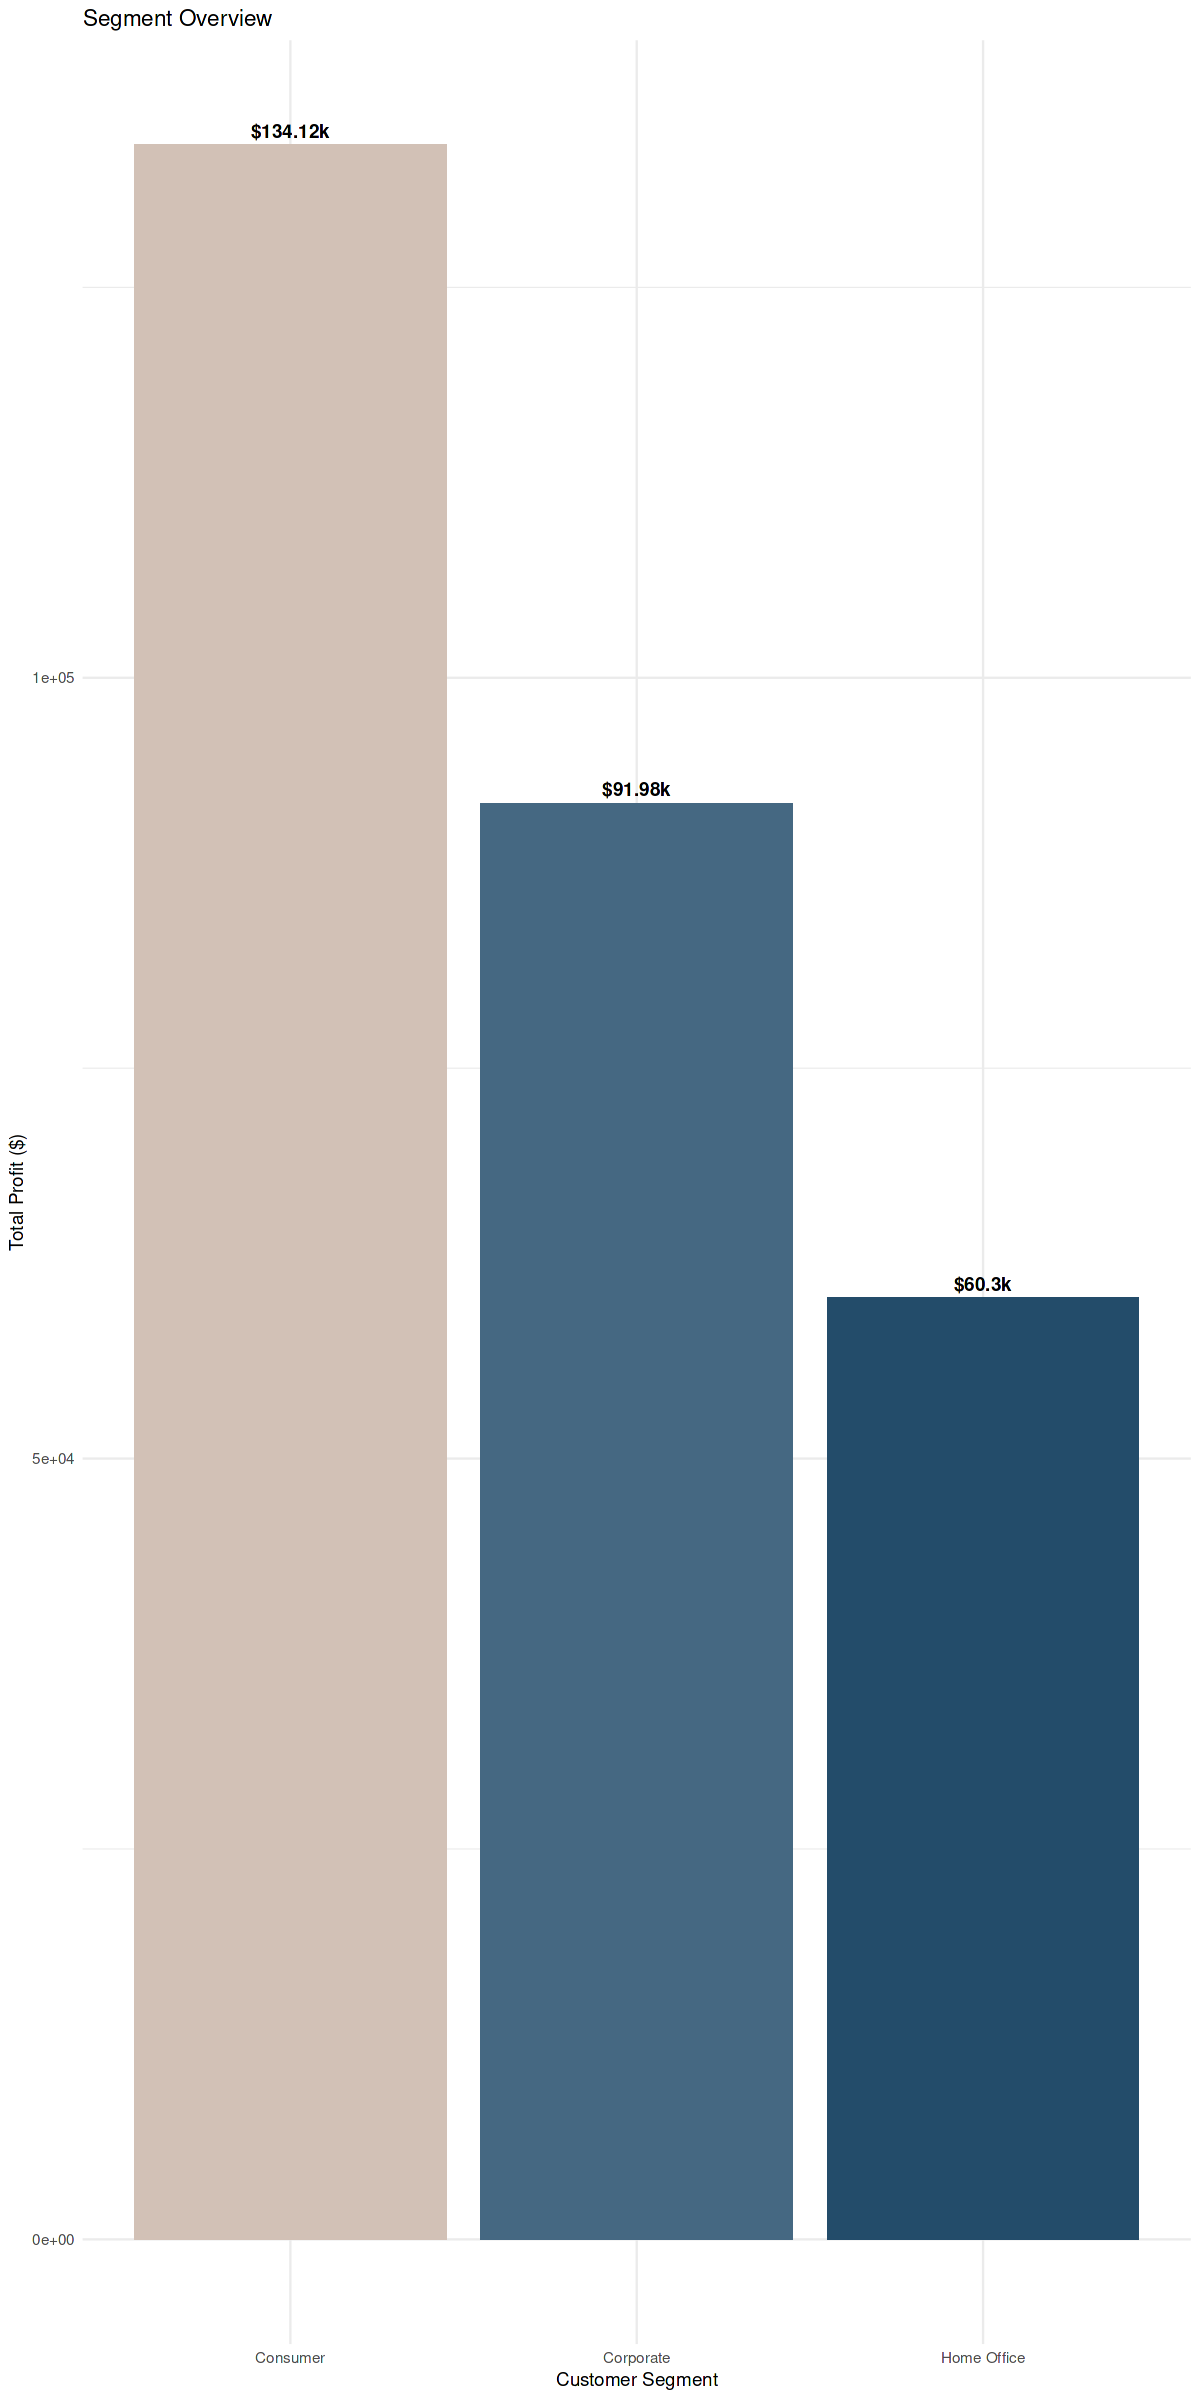

In [39]:
# plot
ggplot(
    segment_overview,
    aes(x = Segment, y = total_profit, fill = Segment)
) + 
geom_col() +
scale_fill_manual(values = c("Consumer" = "#D2C1B6", 
                            "Corporate" = "#456882", 
                            "Home Office" = "#234C6A")) +
labs(
    title = "Segment Overview",
    x = "Customer Segment",
    y = "Total Profit ($)"
) + 
theme_minimal() +
theme(legend.position = "none") +
geom_text(
    aes(label = paste0("$", round((total_profit / 1000), 2), "k")),
    vjust = -0.5,
    fontface = "bold"
)


In [40]:
# Segment Category
segment_category <- superstore %>%
group_by(Segment, Category) %>%
summarise(
    orders = n(),
    total_profit = sum(Profit),
    profit_margin = (sum(Profit) / sum(Sales)) * 100,
    .groups = "drop"
) %>%
arrange(desc(total_profit))

segment_category

Segment,Category,orders,total_profit,profit_margin
<chr>,<chr>,<int>,<dbl>,<dbl>
Consumer,Technology,951,70797.810,17.420725
Consumer,Office Supplies,3127,56330.321,15.477398
Corporate,Technology,554,44166.998,17.921273
Corporate,Office Supplies,1820,40227.320,17.438849
Home Office,Technology,342,30490.140,16.633646
Home Office,Office Supplies,1079,25933.160,20.843503
Corporate,Furniture,646,7584.816,3.311860
Consumer,Furniture,1113,6991.079,1.787774
Home Office,Furniture,362,3875.378,3.178345


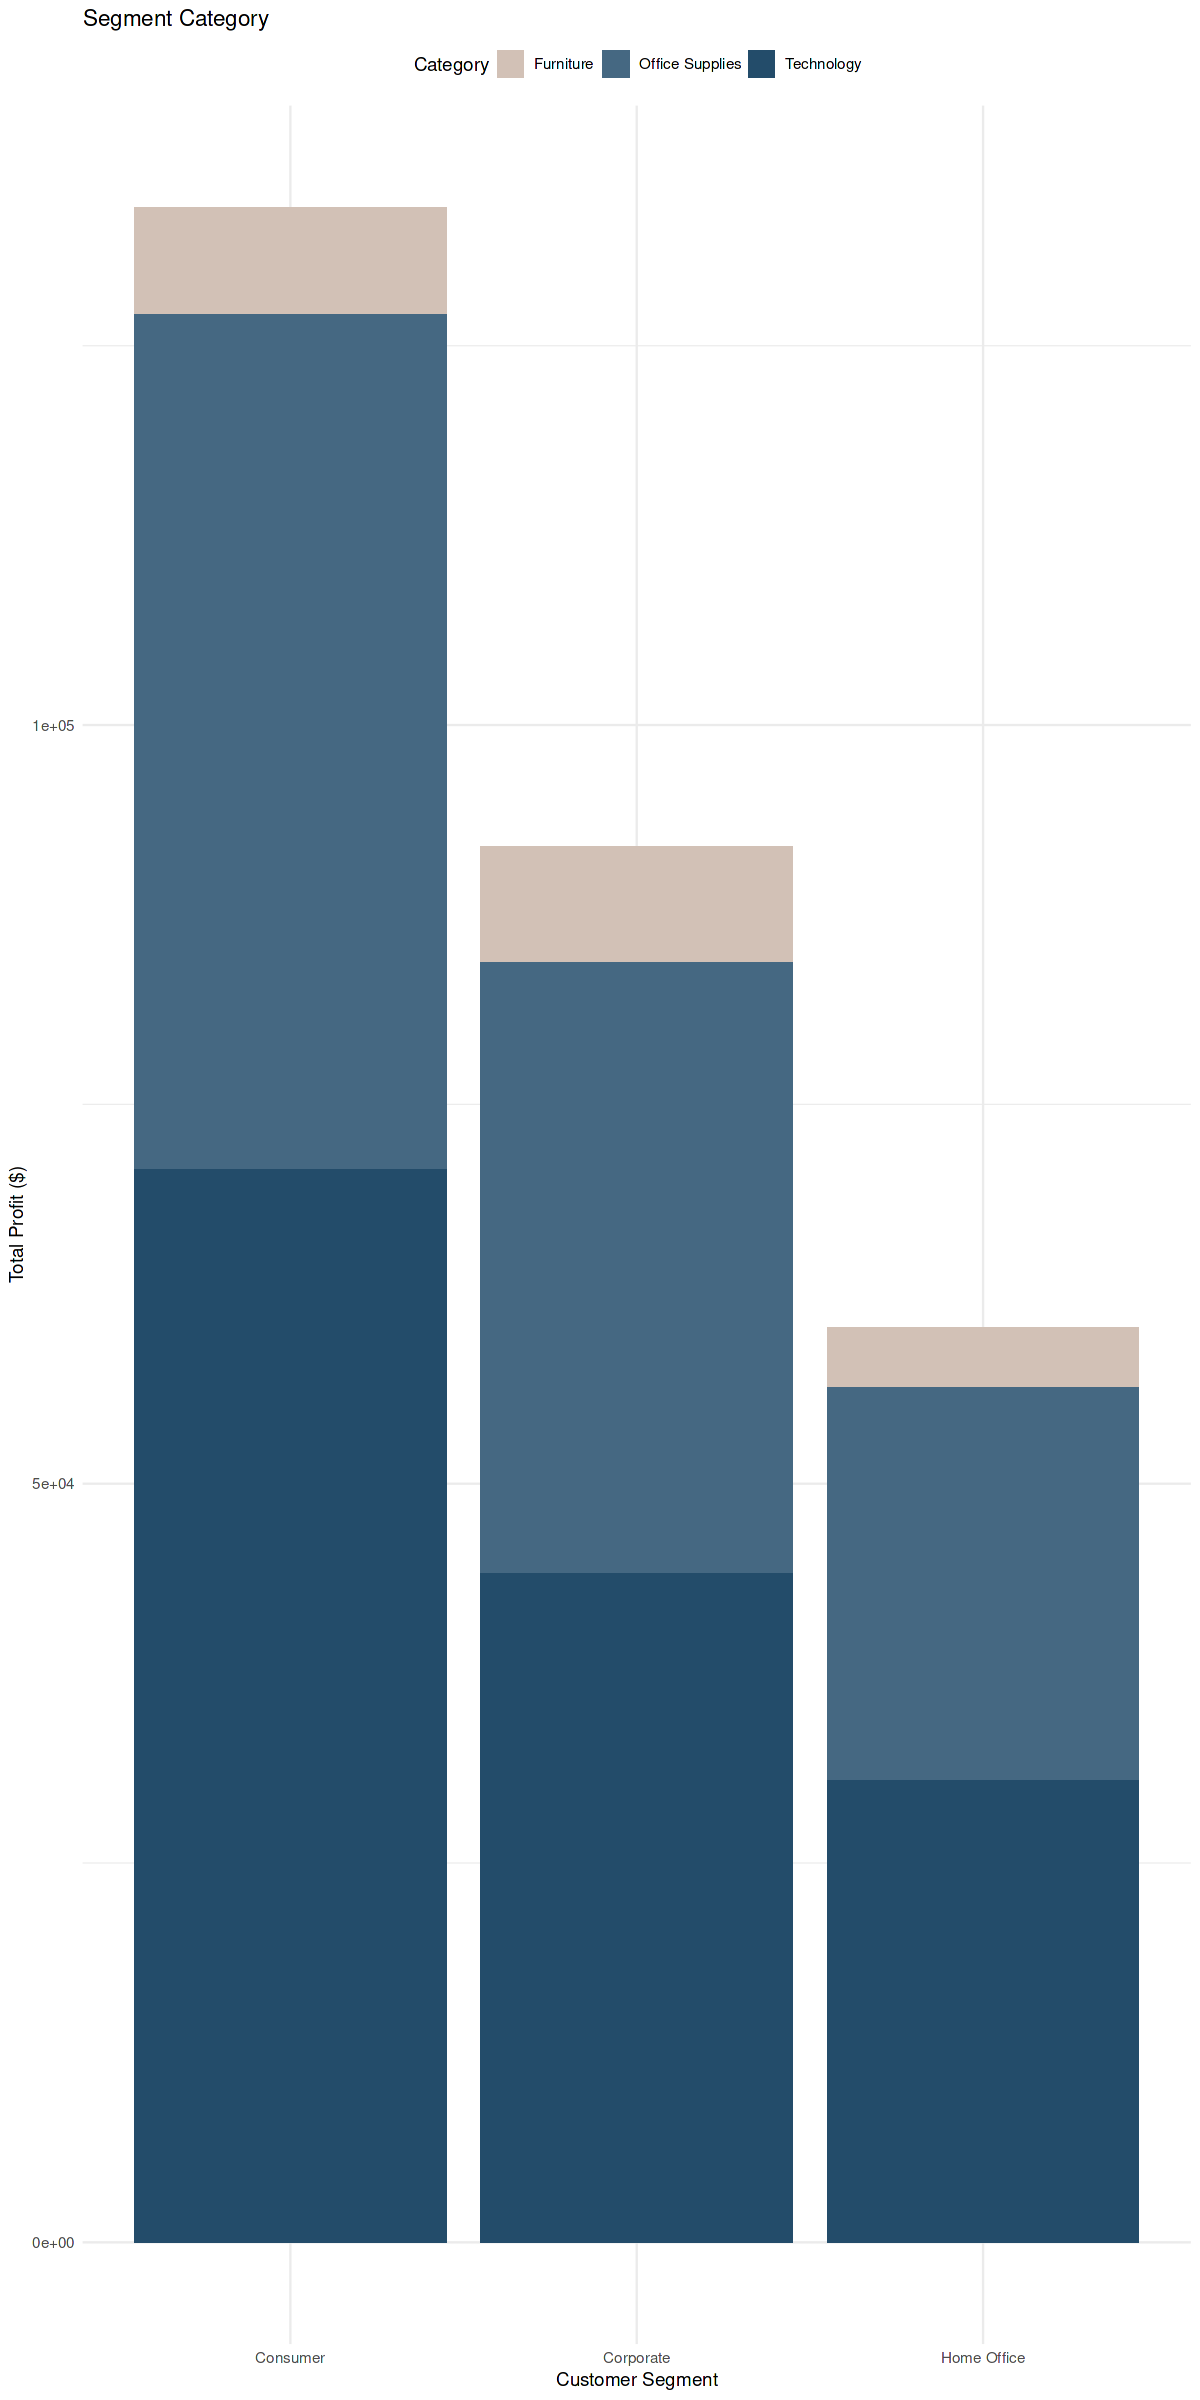

In [41]:
# plot
ggplot(
    segment_category,
    aes(x = Segment, y = total_profit, fill = Category)
) + 
geom_col() +
scale_fill_manual(values = c("Furniture" = "#D2C1B6", 
                            "Office Supplies" = "#456882", 
                            "Technology" = "#234C6A")) +
labs(
    title = "Segment Category",
    x = "Customer Segment",
    y = "Total Profit ($)"
) + 
theme_minimal() +
theme(legend.position = "top")


In [42]:
# Segment Discount
segment_discount <- superstore %>%
mutate(
    Discount_Level = case_when(
      Discount == 0 ~ "No Discount",
      Discount > 0 & Discount <= 0.2 ~ "Low (1-20%)",
      Discount > 0.2 & Discount <= 0.4 ~ "Medium (21-40%)",
      Discount > 0.4 ~ "High (40%+)"
    )
) %>%
group_by(
    Segment, Discount_Level
) %>%
summarise(
    orders = n(),
    total_profit = sum(Profit),
    avg_profit = mean(Profit),
    .groups = "drop"
)

segment_discount

Segment,Discount_Level,orders,total_profit,avg_profit
<chr>,<chr>,<int>,<dbl>,<dbl>
Consumer,High (40%+),494,-55244.178,-111.83032
Consumer,Low (1-20%),1995,48107.409,24.11399
Consumer,Medium (21-40%),241,-16645.983,-69.07047
Consumer,No Discount,2461,157901.961,64.16171
Corporate,High (40%+),281,-26632.204,-94.77653
Corporate,Low (1-20%),1173,29599.115,25.23369
Corporate,Medium (21-40%),139,-13138.560,-94.52201
Corporate,No Discount,1427,102150.782,71.58429
Home Office,High (40%+),158,-17682.209,-111.91271


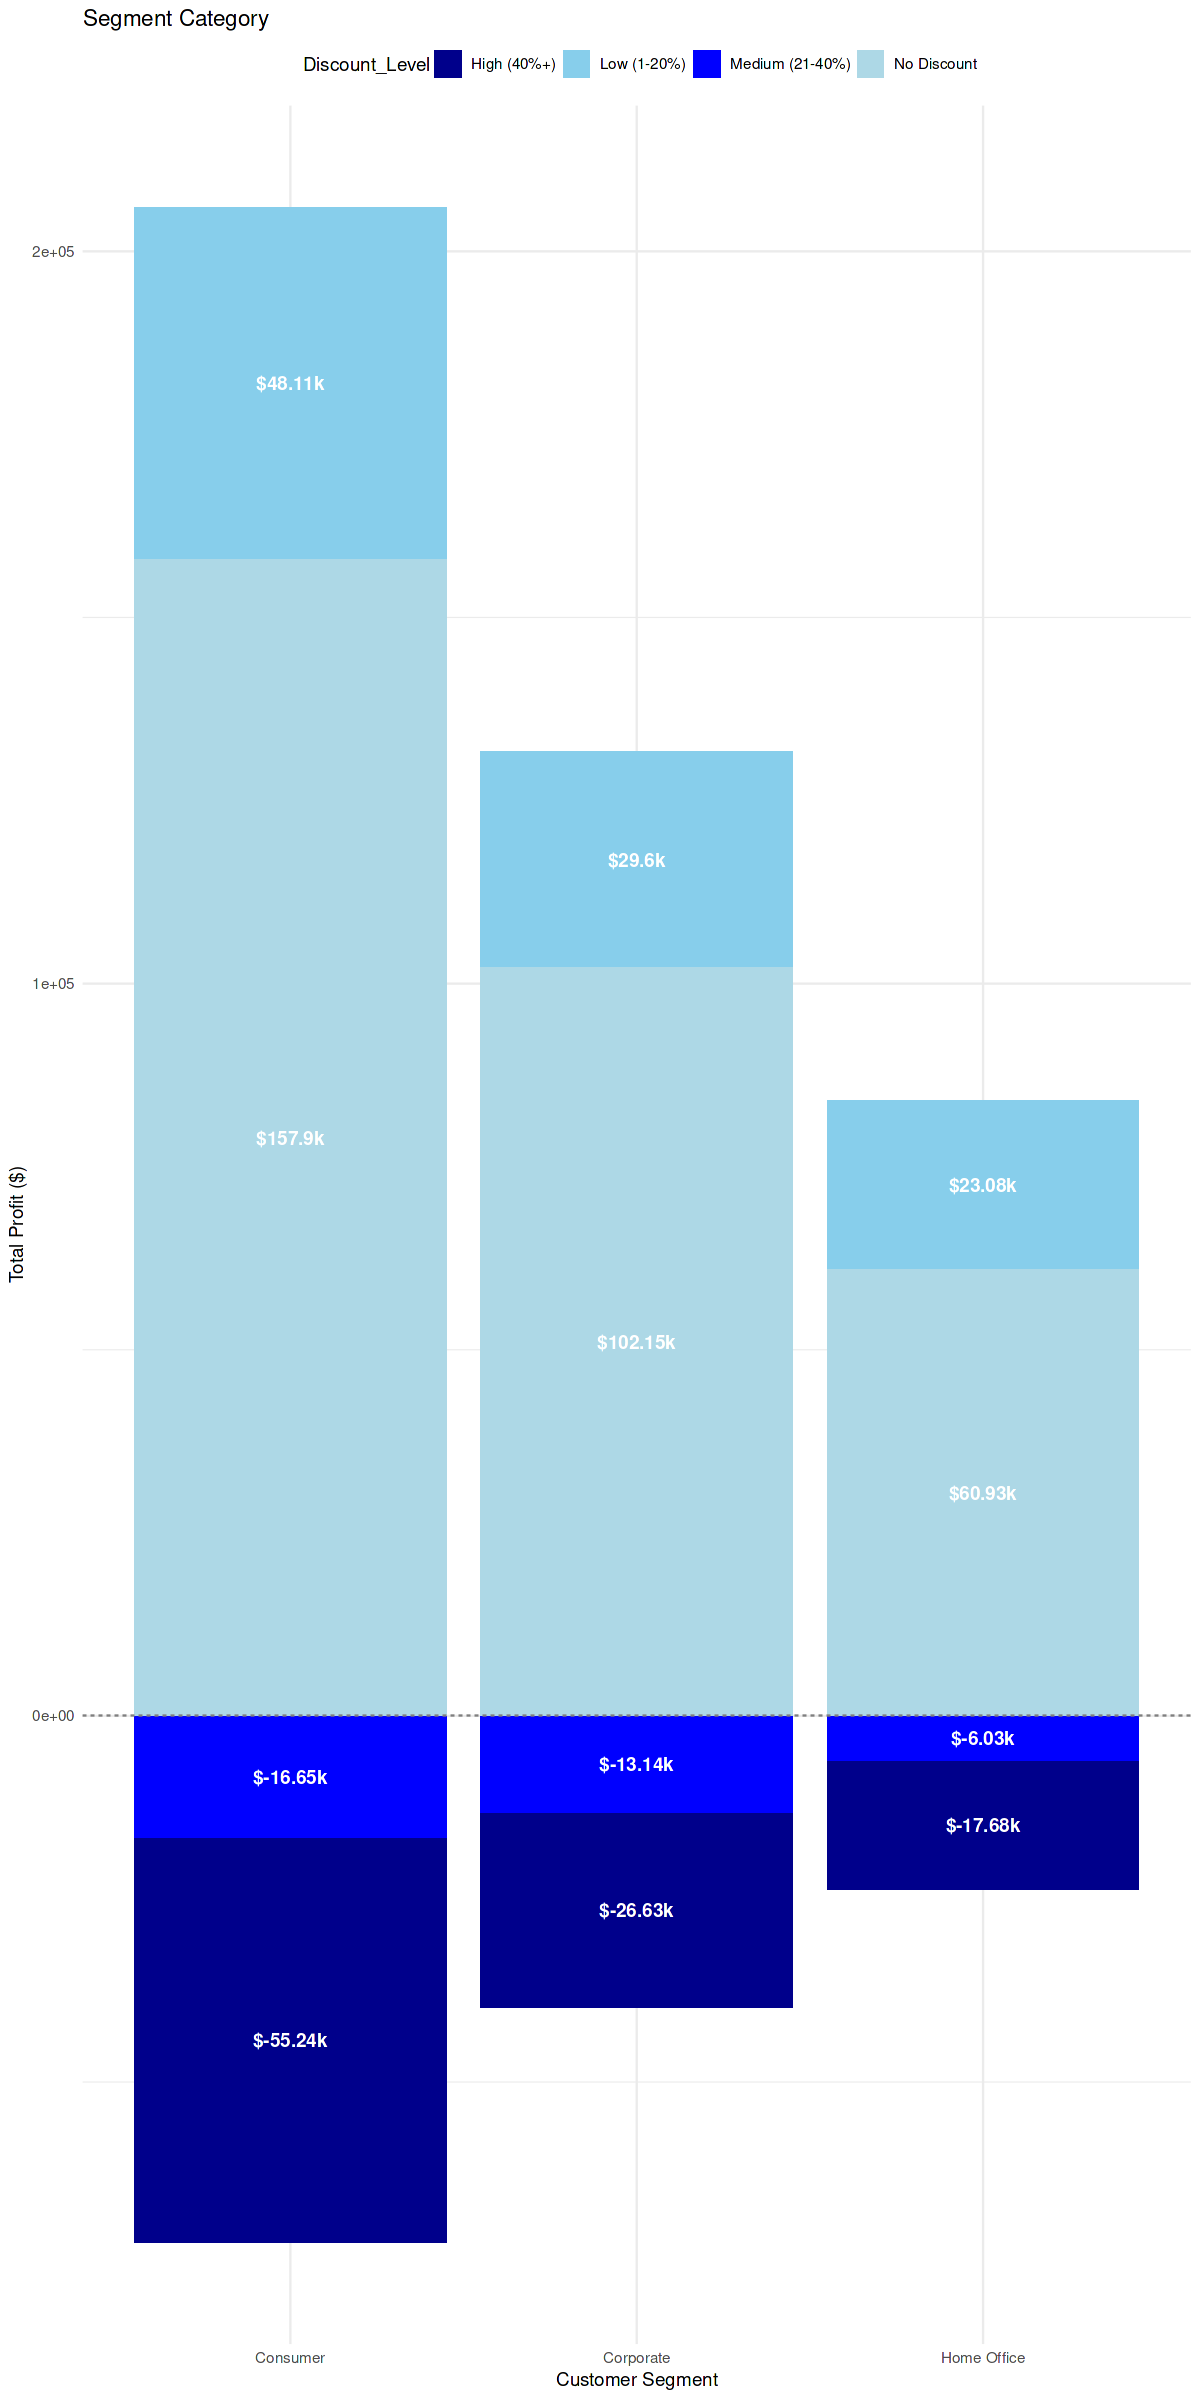

In [43]:
# plot
ggplot(
    segment_discount,
    aes(x = Segment, y = total_profit, fill = Discount_Level)
) + 
geom_col() +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
scale_fill_manual(
    values = c("No Discount" = "lightblue", 
               "Low (1-20%)" = "skyblue", 
               "Medium (21-40%)" = "blue", 
               "High (40%+)" = "darkblue") 
) +
labs(
    title = "Segment Category",
    x = "Customer Segment",
    y = "Total Profit ($)"
) + 
theme_minimal() +
theme(legend.position = "top") +
geom_text(
    aes(label = paste0("$", round(total_profit/1000, 2), "k")),
    position = position_stack(vjust=0.5),
    color = "white",
    fontface = "bold"
)

## Trend Analysis